✓ Generated: pruning_comparison.csv, pruning_table.html, *.png charts

Total rows: 35

Top 5 configurations by accuracy retention:
            method  sparsity  accuracy  acc_drop  pass
2     Unstructured       0.7    0.9276   -0.0006  True
5       Structured       0.1    0.9322   -0.0002  True
1     Unstructured       0.5    0.9271   -0.0001  True
10       Magnitude       0.3    0.9321   -0.0001  True
20  Lottery Ticket       0.3    0.9321   -0.0001  True


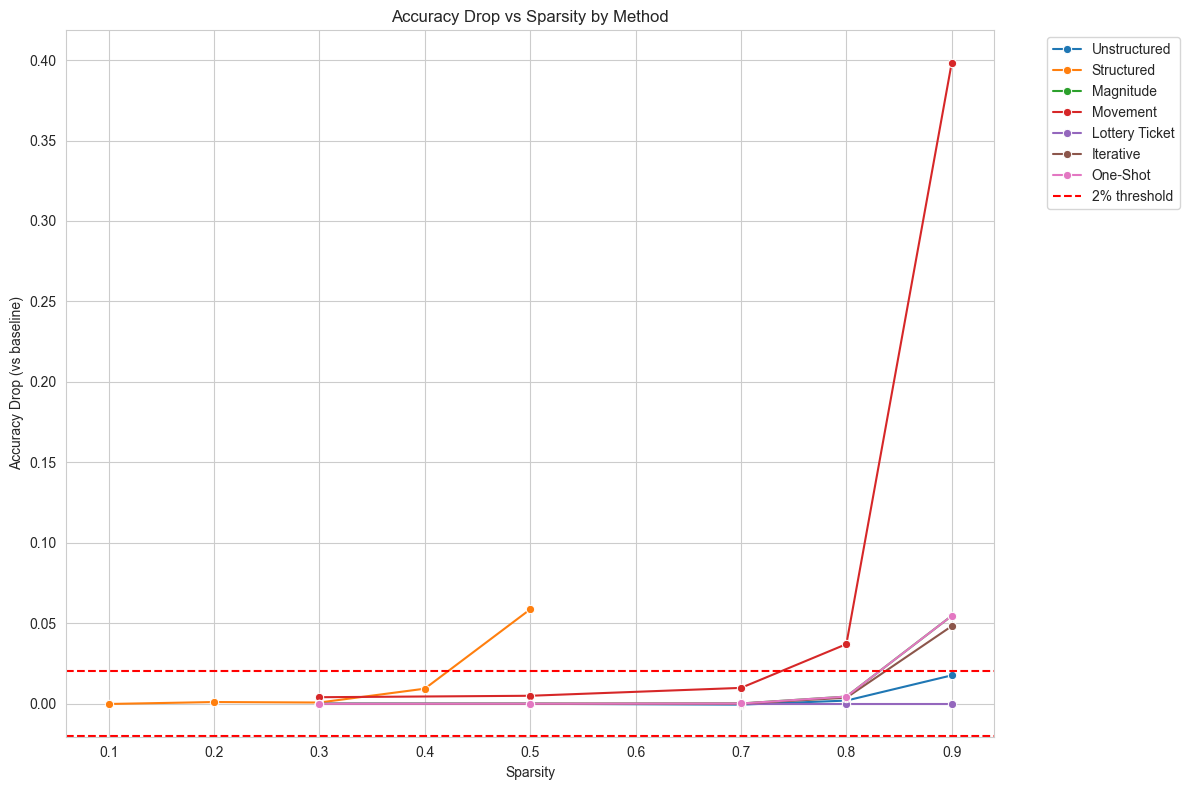

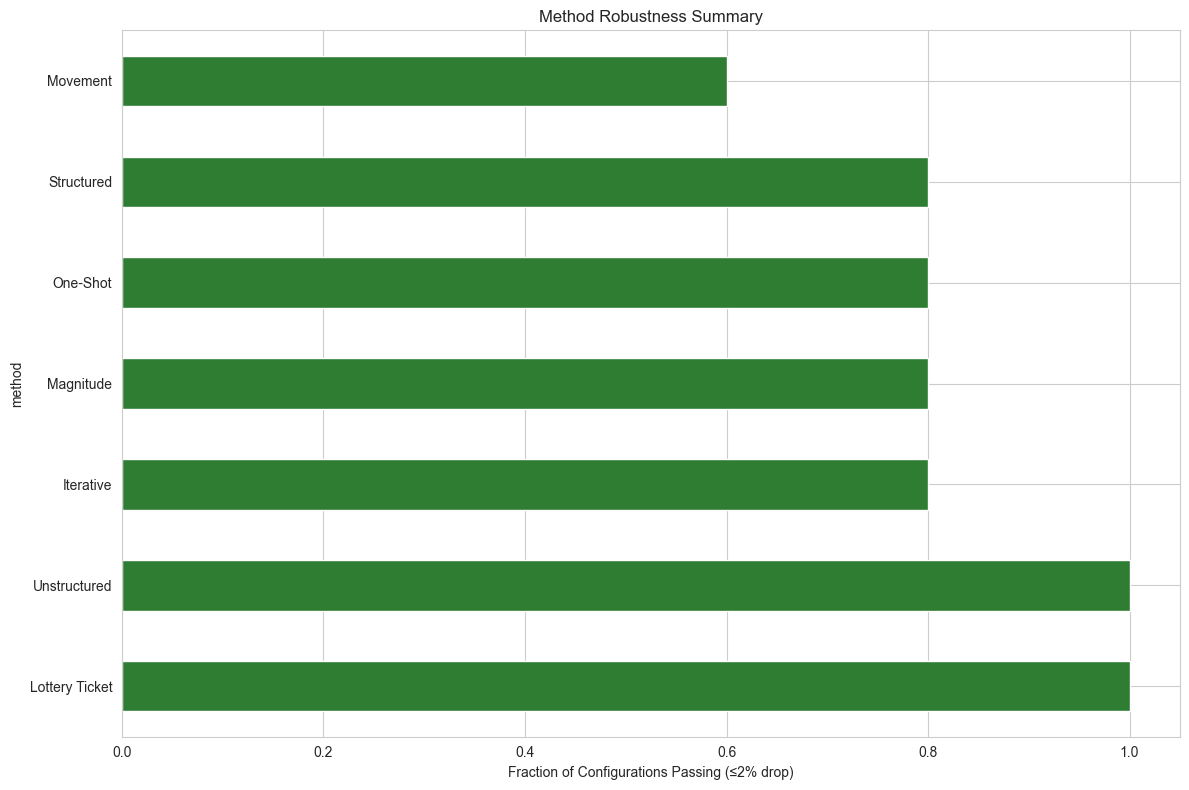

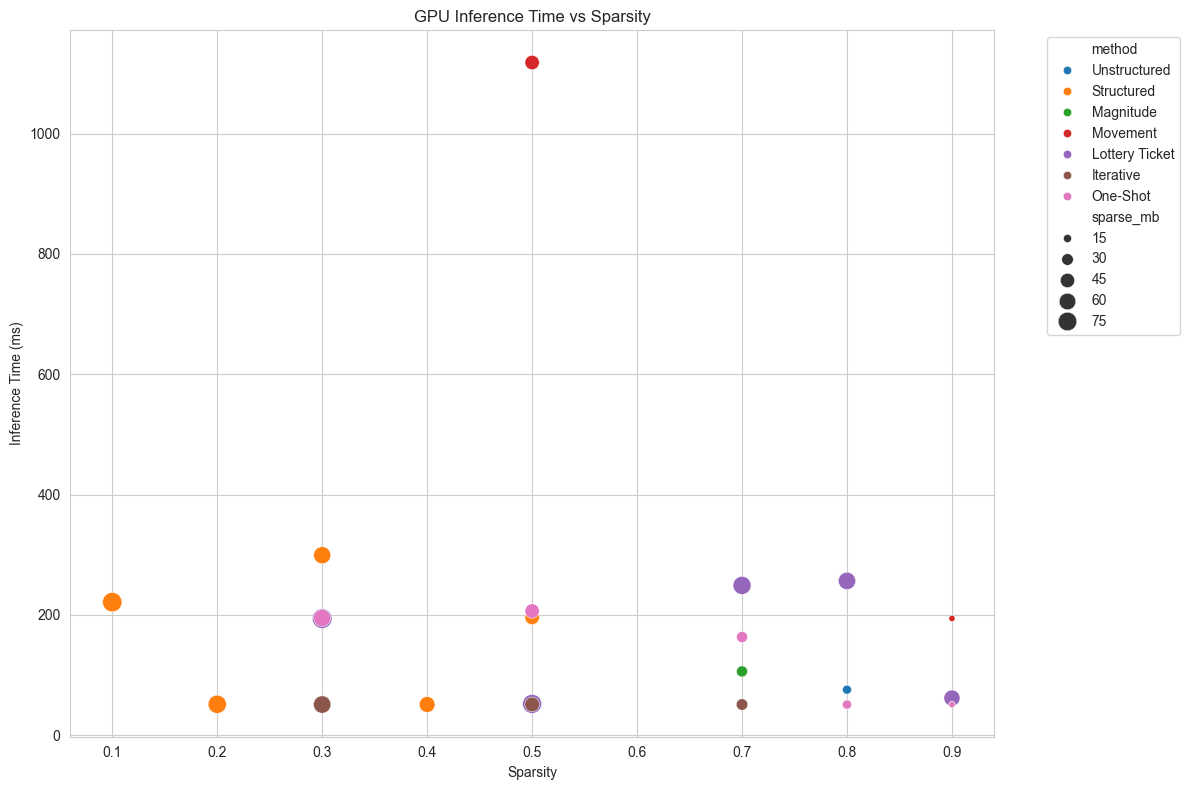

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def load_pruning_data(json_files):
    rows = []
    
    for file in json_files:
        with open(file, 'r') as f:
            data = json.load(f)
        
        method = data['method'].strip()
        baseline = data['baseline']
        base_acc = baseline['accuracy']
        base_f1 = baseline['f1']
        
        # Handle different result structures
        if method == 'lottery_ticket_hypothesis':
            results_list = data.get('results', [])
            for r in results_list:
                row = {
                    'method': 'Lottery Ticket',
                    'sparsity': round(r['target_sparsity'], 2),
                    'accuracy': r['winning_ticket_accuracy'],
                    'f1': r['winning_ticket_f1'],
                    'acc_drop': r['winning_ticket_accuracy_drop'],
                    'active_params': r['params_active'],
                    'sparse_mb': r['size_sparse_theoretical_mb'],
                    'infer_gpu_ms': r['inference_gpu_ms'],
                    'pass': abs(r['winning_ticket_accuracy_drop']) <= 0.02
                }
                rows.append(row)
        
        elif method == 'iterative_pruning':
            # Use checkpointed_results for standard sparsity points (0.3, 0.5, 0.7, 0.8, 0.9)
            results_list = data.get('checkpointed_results', [])
            for r in results_list:
                row = {
                    'method': 'Iterative',
                    'sparsity': round(r['checkpoint_target'], 2),
                    'accuracy': r['accuracy'],
                    'f1': r['f1'],
                    'acc_drop': r['accuracy_drop'],
                    'active_params': r['params_active'],
                    'sparse_mb': r['size_sparse_theoretical_mb'],
                    'infer_gpu_ms': r['inference_gpu_ms'],
                    'pass': abs(r['accuracy_drop']) <= 0.02
                }
                rows.append(row)
        
        elif method == 'magnitude_pruning':
            results_list = data.get('results', [])
            for r in results_list:
                # Keep only global_l1 for fair comparison
                if r.get('criterion') != 'global_l1':
                    continue
                row = {
                    'method': 'Magnitude',
                    'sparsity': round(r['target_sparsity'], 2),
                    'accuracy': r['accuracy'],
                    'f1': r['f1'],
                    'acc_drop': r['accuracy_drop'],
                    'active_params': r['params_active'],
                    'sparse_mb': r['size_sparse_theoretical_mb'],
                    'infer_gpu_ms': r['inference_gpu_ms'],
                    'pass': abs(r['accuracy_drop']) <= 0.02
                }
                rows.append(row)
        
        elif method == 'oneshot_pruning':
            results_list = data.get('results', [])
            for r in results_list:
                # Skip random variant
                if r.get('variant') == 'oneshot_random':
                    continue
                row = {
                    'method': 'One-Shot',
                    'sparsity': round(r['target_sparsity'], 2),
                    'accuracy': r['accuracy'],
                    'f1': r['f1'],
                    'acc_drop': r['accuracy_drop'],
                    'active_params': r['params_active'],
                    'sparse_mb': r['size_sparse_theoretical_mb'],
                    'infer_gpu_ms': r['inference_gpu_ms'],
                    'pass': abs(r['accuracy_drop']) <= 0.02
                }
                rows.append(row)
        
        else:
            # Unstructured, Structured, Movement
            results_list = data.get('results', [])
            for r in results_list:
                # For structured, use filter_pruning_ratio as sparsity
                sp = r.get('target_sparsity') or r.get('filter_pruning_ratio') or r.get('structured_sparsity')
                if sp is None:
                    continue
                    
                row = {
                    'method': method.replace('_pruning','').replace('_',' ').title(),
                    'sparsity': round(sp, 2),
                    'accuracy': r['accuracy'],
                    'f1': r['f1'],
                    'acc_drop': r['accuracy_drop'],
                    'active_params': r['params_active'],
                    'sparse_mb': r['size_sparse_theoretical_mb'],
                    'infer_gpu_ms': r['inference_gpu_ms'],
                    'pass': abs(r['accuracy_drop']) <= 0.02
                }
                rows.append(row)
    
    return pd.DataFrame(rows)

# Load your files
json_files = [
    '1_unstructured_Pruning.json',
    '2_structured_Pruning.json', 
    '3_magnitude_Pruning.json',
    '4_movement_Pruning.json',
    '5_lottery_ticket_Pruning.json',
    '6_iterative_Pruning.json',
    '7_oneshot_Pruning.json'
]

df = load_pruning_data(json_files)

# === EXPORT FOR REPORT ===
df.to_csv('pruning_comparison.csv', index=False)

# HTML table
html_table = df.sort_values(['method','sparsity']).to_html(index=False, float_format='%.4f')
with open('pruning_table.html', 'w') as f:
    f.write(f"""
    <style>
        table {{ border-collapse: collapse; width: 100%; font-size: 11px; }}
        th {{ background: #f5f5f5; padding: 8px; text-align: left; border: 1px solid #ddd; }}
        td {{ padding: 6px 8px; border: 1px solid #eee; }}
        .pass {{ background: #e8f5e9; }}
        .fail {{ background: #ffebee; }}
    </style>
    {html_table}
    """)

# === VISUALIZATIONS ===
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [12, 8]

# Plot 1: Accuracy Drop vs Sparsity
plt.figure()
sns.lineplot(data=df, x='sparsity', y='acc_drop', hue='method', marker='o')
plt.axhline(y=0.02, color='red', linestyle='--', label='2% threshold')
plt.axhline(y=-0.02, color='red', linestyle='--')
plt.title('Accuracy Drop vs Sparsity by Method')
plt.xlabel('Sparsity')
plt.ylabel('Accuracy Drop (vs baseline)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('acc_drop_vs_sparsity.png', dpi=300, bbox_inches='tight')

# Plot 2: Pass/Fail Summary
plt.figure()
pass_summary = df.groupby('method')['pass'].mean().sort_values(ascending=False)
pass_summary.plot(kind='barh', color=['#2e7d32' if v > 0.5 else '#c62828' for v in pass_summary])
plt.xlabel('Fraction of Configurations Passing (≤2% drop)')
plt.title('Method Robustness Summary')
plt.tight_layout()
plt.savefig('method_robustness.png', dpi=300, bbox_inches='tight')

# Plot 3: Inference Time vs Sparsity
plt.figure()
sns.scatterplot(data=df, x='sparsity', y='infer_gpu_ms', hue='method', size='sparse_mb', sizes=(20,200))
plt.title('GPU Inference Time vs Sparsity')
plt.xlabel('Sparsity')
plt.ylabel('Inference Time (ms)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('inference_time.png', dpi=300, bbox_inches='tight')

print("✓ Generated: pruning_comparison.csv, pruning_table.html, *.png charts")
print(f"\nTotal rows: {len(df)}")
print(f"\nTop 5 configurations by accuracy retention:")
print(df.sort_values('acc_drop').head(5)[['method','sparsity','accuracy','acc_drop','pass']])